현재 해당 서비스를 사용하고 있는 고객은 얼마나 있는가? 
- 96096명

고객은 주로 어디에서 거주하고 있는가? 
-  sao paulo / rio de janeiro / belo horizonte

고객은 주로 어떤 결제 방법을 사용하고 있는가? 
- credit_card

고객들의 평균 거래액은 얼마일까?

일별, 주별, 월별 판매 트랜드는 어떻게 되고있을까?

In [7]:
import pandas as pd

PATH = "00_data"

In [8]:
products = pd.read_csv(f"{PATH}/olist_products_dataset.csv", encoding="utf-8-sig")
customers = pd.read_csv(f"{PATH}/olist_customers_dataset.csv", encoding="utf-8-sig")
geolocation = pd.read_csv(f"{PATH}/olist_geolocation_dataset.csv", encoding="utf-8-sig")
order_items = pd.read_csv(f"{PATH}/olist_order_items_dataset.csv", encoding="utf-8-sig") 
payments = pd.read_csv(f"{PATH}/olist_order_payments_dataset.csv", encoding="utf-8-sig") 
reviews = pd.read_csv(f"{PATH}/olist_order_reviews_dataset.csv", encoding="utf-8-sig") 
orders = pd.read_csv(f"{PATH}/olist_orders_dataset.csv", encoding="utf-8-sig") 
sellers = pd.read_csv(f"{PATH}/olist_sellers_dataset.csv", encoding="utf-8-sig") 
category_name = pd.read_csv(f"{PATH}/product_category_name_translation.csv", encoding="utf-8-sig") 

In [9]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
# 데이터 영역에서 unique가 나왔다면 유일함, 순수한을 의미한다
# unique visitor -> 순 방문자 -> 1명이 3번을 방문했어도 1번 방문한걸로 집계

In [11]:
customers["customer_unique_id"].value_counts()

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
1b6c7548a2a1f9037c1fd3ddfed95f33     7
                                    ..
1c137fe37df712015f6488edafe8ece4     1
5a1680640123fc80e801301a2fb57395     1
046470763123d3d6364f89095b4e47ab     1
aaf22868003377e859049dcf5f0b3fdf     1
206e64e8af2633a2ebe158a7fcb860db     1
Name: count, Length: 96096, dtype: int64

In [14]:
customers["customer_unique_id"].value_counts().max()

17

In [13]:
customers["customer_id"].value_counts()

customer_id
274fa6071e5e17fe303b9748641082c8    1
e5ed7280cd1a3ac2ba29fd6650d8867c    1
c6ece8a5137f3c9c3a3a12302a19a2ac    1
821a7275a08f32975caceff2e08ea262    1
5eef6cce1f34954c9e7004332388ccc7    1
                                   ..
879864dab9bc3047522c92c82e1212b8    1
4f2d8ab171c80ec8364f7c12e35b23ad    1
b2b6027bc5c5109e529d4dc6358b12c3    1
4e7b3e00288586ebd08712fdd0374a03    1
18955e83d337fd6b2def6b18a428ac77    1
Name: count, Length: 99441, dtype: int64

In [16]:
customers["customer_id"].value_counts().max()

1

In [17]:
customers["customer_id"].nunique() # 유니크한 값의 갯수를 확인

99441

In [18]:
customers["customer_unique_id"].nunique() # 전체행수보다 작게 출력되었다는 것은 중복해서 사용된 값이 존재한다는 뜻 / 이게 순수한 값

96096

In [19]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [24]:
# customers_location = customers.groupby("customer_city")["customer_unique_id"].nunique().sort_values(ascending=False)
customers_location = customers.groupby("customer_city")["customer_unique_id"]\
                    .nunique().sort_values(ascending=False)
# nunique() : 인덱스 값인 customer_city를 기준으로  customer_unique_id의 갯수를 파악하기 위한 고유식별값을 연산해주는 매서드
# 파이썬은 문장의 종결을 구분짓는 표기방법이 존재하지 않기 때문에 임의로 개행처리하면 안된다
# 하지만 문장이 너무 길어져서 개행을 해야한다면
# 1) 개행 -> \ 역슬래시 사용
customers_location = customers.groupby("customer_city")["customer_unique_id"]\
                    .nunique()\
                    .sort_values(ascending=False)

# 2) 
customers_location = (
    customers.groupby("customer_city")["customer_unique_id"]
    .nunique().sort_values(ascending=False)
)

customers_location.head(20)

customer_city
sao paulo                14984
rio de janeiro            6620
belo horizonte            2672
brasilia                  2069
curitiba                  1465
campinas                  1398
porto alegre              1326
salvador                  1209
guarulhos                 1153
sao bernardo do campo      908
niteroi                    811
santo andre                769
osasco                     717
santos                     692
goiania                    671
sao jose dos campos        666
fortaleza                  643
sorocaba                   610
recife                     590
jundiai                    547
Name: customer_unique_id, dtype: int64

In [28]:
customers_location_top20 = customers_location.head(20)

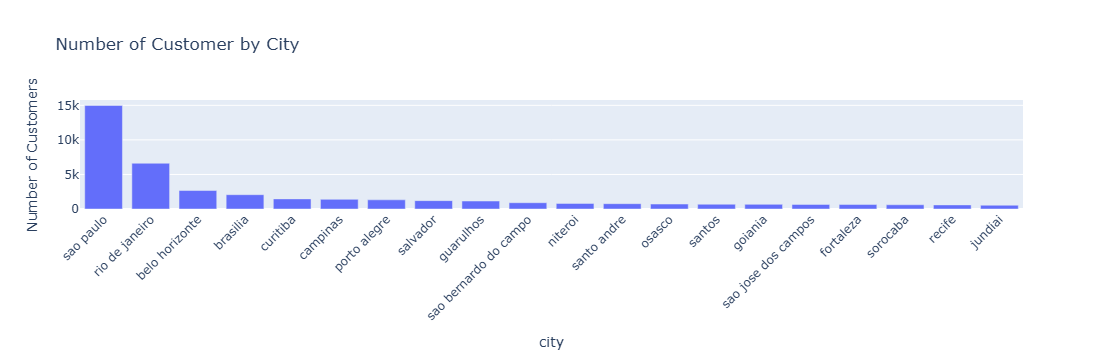

In [37]:
import plotly.express as px

fig = px.bar(
    x = customers_location_top20.index,
    y = customers_location_top20.values,
    title = "Number of Customer by City",
    labels={"x": "city", "y": "Number of Customers"}
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()   

In [34]:
top20_customers_location = customers_location_top20.index

In [38]:
top20_customers_location

Index(['sao paulo', 'rio de janeiro', 'belo horizonte', 'brasilia', 'curitiba',
       'campinas', 'porto alegre', 'salvador', 'guarulhos',
       'sao bernardo do campo', 'niteroi', 'santo andre', 'osasco', 'santos',
       'goiania', 'sao jose dos campos', 'fortaleza', 'sorocaba', 'recife',
       'jundiai'],
      dtype='object', name='customer_city')

In [36]:
type(top20_customers_location)

pandas.core.indexes.base.Index

In [42]:
for index, location in enumerate(list(top20_customers_location)) :
    print(f"TOP {index + 1}. {location}")

TOP 1. sao paulo
TOP 2. rio de janeiro
TOP 3. belo horizonte
TOP 4. brasilia
TOP 5. curitiba
TOP 6. campinas
TOP 7. porto alegre
TOP 8. salvador
TOP 9. guarulhos
TOP 10. sao bernardo do campo
TOP 11. niteroi
TOP 12. santo andre
TOP 13. osasco
TOP 14. santos
TOP 15. goiania
TOP 16. sao jose dos campos
TOP 17. fortaleza
TOP 18. sorocaba
TOP 19. recife
TOP 20. jundiai


In [43]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [44]:
payments.shape

(103886, 5)

In [45]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [47]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [49]:
payments["payment_type"].unique() # 중복을 제거한 상태의 고유 값을 확인하고자 할 때 사용

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [56]:
payments = payments[payments["payment_type"] != "not_defined"]

In [57]:
payments["payment_type"].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card'], dtype=object)

In [58]:
payment_type_count = (payments.groupby("payment_type")["order_id"]
                      .nunique()
                      .sort_values(ascending=False)
                     )
payment_type_count

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
Name: order_id, dtype: int64

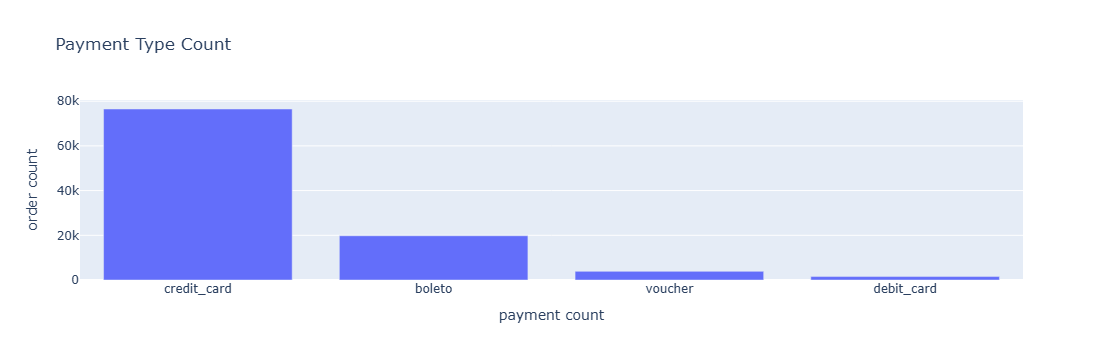

In [60]:
import plotly.express as px

fig = px.bar(
    x = payment_type_count.index,
    y = payment_type_count.values,
    title = "Payment Type Count",
    labels = {"x": "payment count", "y": "order count"}
)

fig.show()

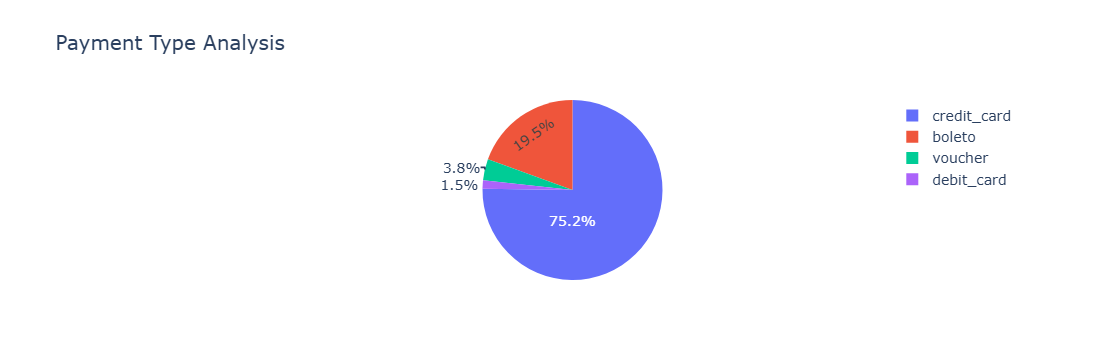

In [71]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Pie(
        labels=payment_type_count.index,
        values=payment_type_count.values,
        textinfo="percent", # label+percent, label, value, percent(디폴트값)
        insidetextorientation="tangential" # horizontal, radial, tangential
    )
)

fig.update_layout(
    {
        "title": "Payment Type Analysis",
        "font": {
            "size": 14
        }
    }
)


fig.show()